# Attentional State Classifier — Random Forrest Classifier


## CELL 1  Install Dependencies (pinned for reproducibility, §7)

In [ ]:
# All versions are written to package_versions.txt and saved with the model.
!pip -q install -U \
  "transformers>=4.44.0" \
  "accelerate>=0.33.0" \
  "datasets>=2.20.0" \
  "peft>=0.12.0" \
  "trl>=0.9.0" \
  "bitsandbytes>=0.43.3" \
  "evaluate>=0.4.2" \
  "scikit-learn>=1.3.0" \
  "seaborn>=0.13.0"

# Capture exact resolved versions — saved with the checkpoint later.
!pip freeze | grep -E \
  "^(transformers|accelerate|datasets|peft|trl|bitsandbytes|evaluate|scikit.learn|seaborn|torch)==" \
  > /tmp/pkg_versions.txt
!cat /tmp/pkg_versions.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 151.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 145.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 57.6 MB/s eta 0:00:00
accelerate==1.13.0
bitsandbytes==0.49.2
datasets==4.8.4
evaluate==0.4.6
peft==0.18.1
scikit-learn==1.8.0
seaborn==0.13.2
torch==2.10.0+cu128
transformers==5.5.0
trl==1.0.0


## Cell 2: Imports + Reproducability + Environment report
Thesis Defensible: You can cite fixed seeds + version logging for reproducibility

In [ ]:
# A single set_seed() call fixes every source of randomness:
#   Python's random, NumPy, PyTorch CPU, PyTorch CUDA, and PYTHONHASHSEED.
# All downstream splits and augmentation use this seed.
# ─────────────────────────────────────────────────────────────────────────────
import os, json, random, math, time, shutil, warnings
from typing import Dict, Any, Optional, List, Tuple
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm

import torch
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig
from datasets import Dataset
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score, classification_report,
    roc_curve, precision_recall_curve, auc,
)
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 12})

# ── Global constants ─────────────────────────────────────────────────────────
SEED            = 42
STATE_KEYS      = ["focused", "drifting", "hyperfocused", "cognitive_overload"]
DRIFT_DROPOUT_P = 0.50      # 50 % of training examples have drift block zeroed
MODEL_NAME      = "Qwen/Qwen2.5-7B-Instruct"
MAX_SEQ_LEN     = 4096      # tokenizer hard truncation limit
MAX_NEW_TOKENS  = 80        # 2-line output ≈ 50 tokens; 80 is a safe ceiling

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)

LIBRARY_VERSIONS = {
    "torch": torch.__version__,
    "transformers": transformers.__version__,
    "python": os.sys.version.split()[0],
}
print("Versions:", LIBRARY_VERSIONS)

Versions: {'torch': '2.10.0+cu128', 'transformers': '5.5.0', 'python': '3.12.13'}


## CELL 3  GPU Health Check

In [ ]:
# QLoRA on Qwen2.5-7B requires ≥ 15 GB VRAM.
# Colab A100 (40 GB) and L4 (24 GB) are both sufficient.
assert torch.cuda.is_available(), "No GPU found — switch Colab runtime to A100/L4/T4."

props      = torch.cuda.get_device_properties(0)
total_vram = props.total_memory / 1e9
free_vram  = (props.total_memory - torch.cuda.memory_allocated()) / 1e9

print(f"GPU        : {props.name}")
print(f"Total VRAM : {total_vram:.2f} GB")
print(f"Free  VRAM : {free_vram:.2f} GB")

LIBRARY_VERSIONS["gpu"]     = props.name
LIBRARY_VERSIONS["vram_gb"] = round(total_vram, 2)

GPU        : NVIDIA A100-SXM4-40GB
Total VRAM : 42.41 GB
Free  VRAM : 42.41 GB


## Cell 4: mount drive, Load Data, Define Core helpers

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

DATA_PATH   = "/content/drive/MyDrive/exports/supervised.jsonl"
OUTPUT_DIR  = "/content/drive/MyDrive/exports/RF"
FIGURES_DIR = "/content/drive/MyDrive/exports/figures"
os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

assert os.path.exists(DATA_PATH), f"Not found: {DATA_PATH}"

def safe_jsonl_load(path: str) -> List[Dict[str, Any]]:
    rows = []
    with open(path, encoding="utf-8") as f:
        for i, line in enumerate(f):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except Exception as e:
                raise ValueError(f"Line {i}: {e}")
    return rows

def extract_label_dict(ex: Dict[str, Any]) -> Dict[str, int]:
    """Return {state: int percentage} from 'labels' field. Must sum to 100."""
    labels = ex.get("labels")
    if labels is None:
        raise KeyError("No 'labels' field.")
    return {k: int(labels.get(k, 0)) for k in STATE_KEYS}

def label_valid(lbl: Dict[str, int]) -> bool:
    return sum(lbl.values()) == 100 and all(v >= 0 for v in lbl.values())

def primary_state(ex: Dict[str, Any]) -> str:
    lbl = extract_label_dict(ex)
    return max(lbl, key=lbl.get)

raw = safe_jsonl_load(DATA_PATH)
print(f"Loaded {len(raw)} rows")

# ── Integrity filter ─────────────────────────────────────────────────────────
filtered = []
for ex in raw:
    try:
        if label_valid(extract_label_dict(ex)):
            filtered.append(ex)
    except Exception:
        pass

print(f"After integrity filter: {len(filtered)} / {len(raw)} (dropped {len(raw)-len(filtered)})")
raw = filtered

DATA_LINEAGE = {
    "source": DATA_PATH,
    "n_rows": len(raw),
    "loaded_at": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 1499 rows
After integrity filter: 1499 / 1499 (dropped 0)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# RUN MANAGEMENT — Auto-numbered output directory
#
# Scans OUTPUT_DIR for existing run_NNN folders and creates the next one.
# All figures, models, and metrics for this execution are isolated under RUN_DIR.
# This makes every run fully reproducible and comparable without overwriting.
import re, json

def _next_run_number(base_dir: str) -> int:
    """Scan base_dir for run_NNN folders and return the next integer."""
    if not os.path.isdir(base_dir):
        return 1
    existing = [
        d for d in os.listdir(base_dir)
        if re.fullmatch(r"run_\d{3}", d) and os.path.isdir(os.path.join(base_dir, d))
    ]
    if not existing:
        return 1
    return max(int(d.split("_")[1]) for d in existing) + 1

RUN_NUM = _next_run_number(OUTPUT_DIR)
RUN_DIR = os.path.join(OUTPUT_DIR, f"run_{RUN_NUM:03d}")
os.makedirs(RUN_DIR, exist_ok=True)

# Canonical file paths — reference these throughout all cells
PATHS = {
    "model":          os.path.join(RUN_DIR, "rf_classifier_v2.pkl"),
    "confusion":      os.path.join(RUN_DIR, "confusion_matrix.png"),
    "roc_pr":         os.path.join(RUN_DIR, "roc_pr_curves.png"),
    "calibration":    os.path.join(RUN_DIR, "calibration_diagram.png"),
    "feat_importance":os.path.join(RUN_DIR, "feature_importance.png"),
    "jsd_dist":       os.path.join(RUN_DIR, "jsd_distribution.png"),
    "ablation":       os.path.join(RUN_DIR, "ablation_study.png"),
    "error_analysis": os.path.join(RUN_DIR, "error_analysis.png"),
    "sensitivity":    os.path.join(RUN_DIR, "sensitivity_analysis.png"),
    "per_user_f1":    os.path.join(RUN_DIR, "per_user_f1.png"),
    "training_meta":  os.path.join(RUN_DIR, "training_meta.json"),
    "final_results":  os.path.join(RUN_DIR, "final_results.json"),
    "sample_output":  os.path.join(RUN_DIR, "sample_output.txt"),
}

print(f"Run {RUN_NUM:03d} → {RUN_DIR}")
print("All outputs will be saved to this directory.")

Run 007 → /content/drive/MyDrive/exports/RF/run_007
All outputs will be saved to this directory.


## Cell 5 — EDA: label distribution & class imbalance

Class imbalance directly determines the choice of primary metric.

With a max/min imbalance ratio > 2, Accuracy is misleading (a classifier
predicting only "focused" achieves ~36% accuracy while doing nothing useful).

Macro-F1 gives equal weight to each class and is the standard choice
for imbalanced multi-class classification (Sokolova & Lapalme, 2009).

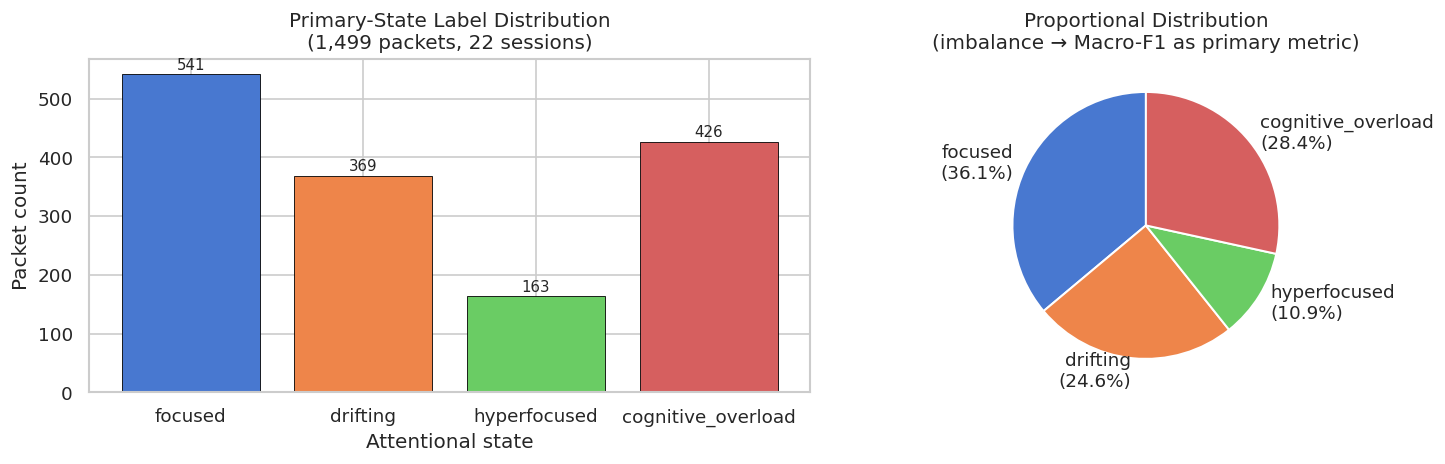

Imbalance ratio (max/min class): 3.32×
→ Primary metric: Macro-F1   Secondary: Accuracy, per-class F1, ROC-AUC, PR-AUC


In [ ]:
primaries    = [primary_state(ex) for ex in raw]
state_counts = Counter(primaries)
total        = len(raw)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = sns.color_palette("muted", 4)

# Absolute bar chart
bars = axes[0].bar(STATE_KEYS, [state_counts[s] for s in STATE_KEYS],
                   color=colors, edgecolor="black", linewidth=0.5)
axes[0].set_title("Primary-State Label Distribution\n(1,499 packets, 22 sessions)")
axes[0].set_ylabel("Packet count")
axes[0].set_xlabel("Attentional state")
for bar, s in zip(bars, STATE_KEYS):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
                 f"{state_counts[s]}", ha="center", va="bottom", fontsize=9)

# Proportional pie
pie_labels = [f"{s}\n({state_counts[s]/total*100:.1f}%)" for s in STATE_KEYS]
axes[1].pie([state_counts[s] for s in STATE_KEYS], labels=pie_labels, colors=colors,
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=1.2))
axes[1].set_title("Proportional Distribution\n(imbalance → Macro-F1 as primary metric)")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "01_label_distribution.pdf"), bbox_inches="tight")
plt.show()

imbalance_ratio = max(state_counts.values()) / min(state_counts.values())
print(f"Imbalance ratio (max/min class): {imbalance_ratio:.2f}×")
print("→ Primary metric: Macro-F1   Secondary: Accuracy, per-class F1, ROC-AUC, PR-AUC")

## Cell 6 — EDA: z-score distributions by class

Violin plots reveal which z-scores carry discriminative signal.

Strong class separation in a z-score justifies its prominence in the
system prompt and motivates why the LLM should weight it heavily.

The Spearman correlation heatmap exposes multicollinearity that would inflate feature importance in a naive tabular model.

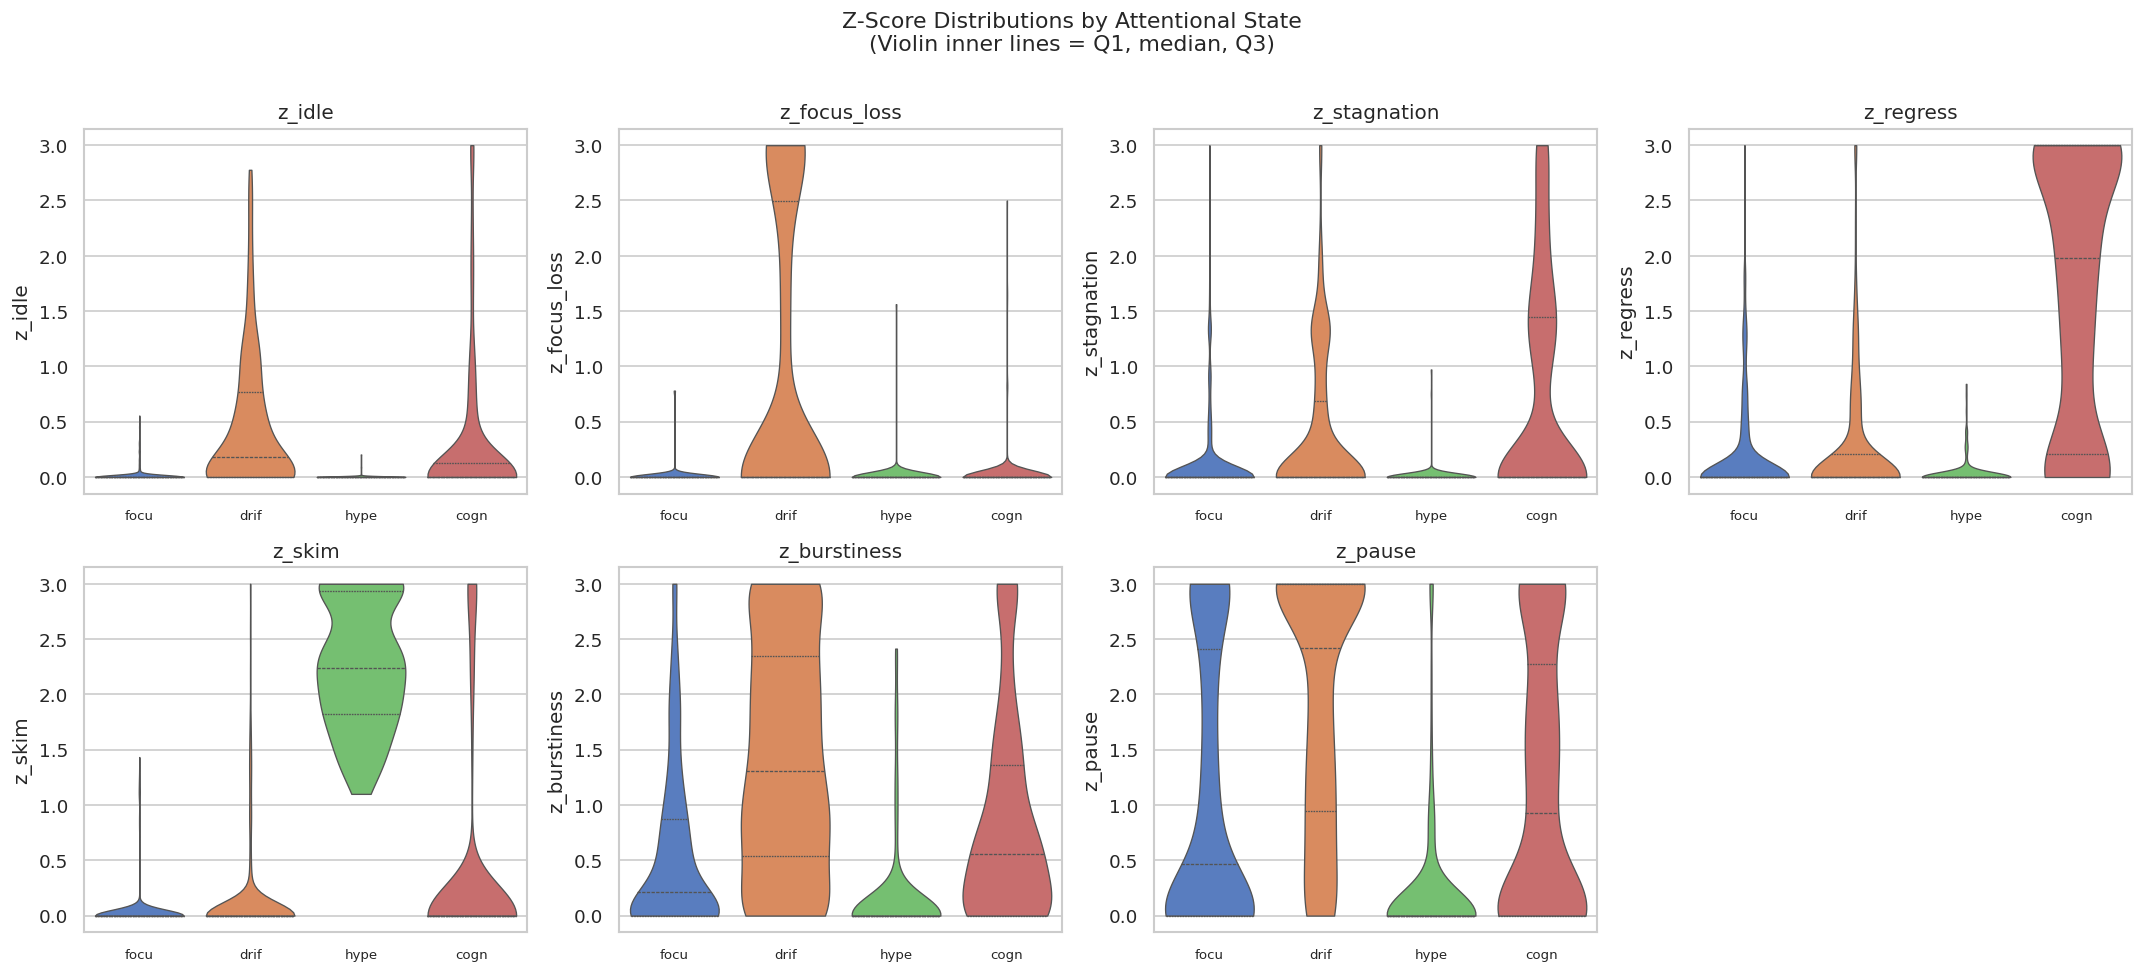

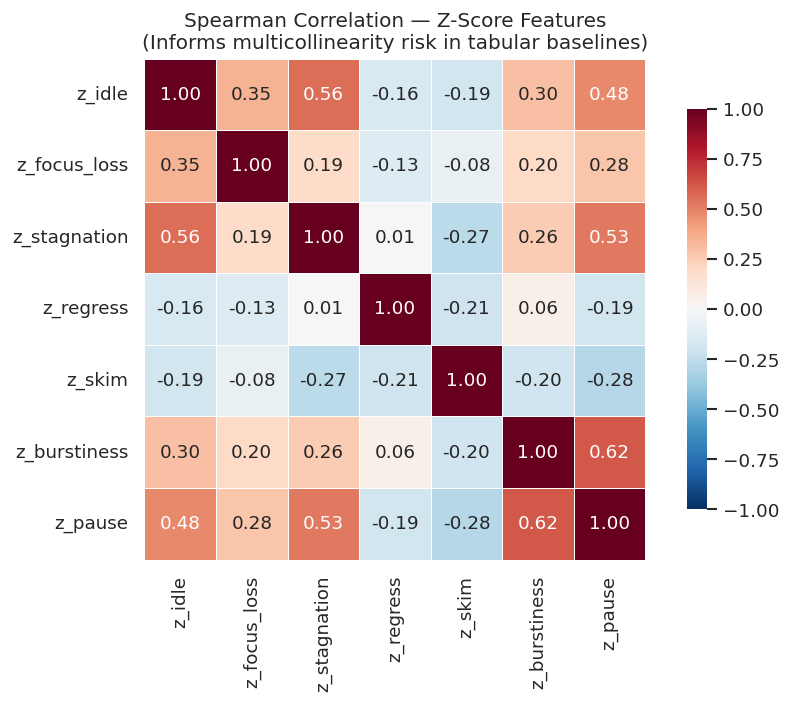

In [ ]:
Z_COLS = ["z_idle","z_focus_loss","z_stagnation","z_regress",
          "z_skim","z_burstiness","z_pause"]

records = []
for ex in raw:
    zs   = ex.get("z_scores", {})
    prim = primary_state(ex)
    row  = {"state": prim}
    for z in Z_COLS:
        row[z] = float(zs.get(z, 0.0))
    records.append(row)

df_z = pd.DataFrame(records)
palette = dict(zip(STATE_KEYS, sns.color_palette("muted", 4)))

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, zf in enumerate(Z_COLS):
    sns.violinplot(data=df_z, x="state", y=zf, ax=axes[i],
                   order=STATE_KEYS, palette=palette,
                   inner="quartile", linewidth=0.8, cut=0)
    axes[i].set_title(zf)
    axes[i].set_xlabel("")
    axes[i].set_xticklabels([s[:4] for s in STATE_KEYS], fontsize=8)
axes[7].set_visible(False)

fig.suptitle("Z-Score Distributions by Attentional State\n"
             "(Violin inner lines = Q1, median, Q3)", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "02_zscore_distributions.pdf"), bbox_inches="tight")
plt.show()

# Spearman correlation (rank-based, appropriate for bounded z-scores)
fig2, ax2 = plt.subplots(figsize=(8, 6))
sns.heatmap(df_z[Z_COLS].corr(method="spearman"), annot=True, fmt=".2f",
            cmap="RdBu_r", vmin=-1, vmax=1, center=0, ax=ax2,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax2.set_title("Spearman Correlation — Z-Score Features\n"
              "(Informs multicollinearity risk in tabular baselines)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "03_zscore_correlation.pdf"), bbox_inches="tight")
plt.show()

## Cell 7 — EDA: per-session distribution + token lengths
The stacked bar chart verifies that each session has a coherent internal
distribution (expected since sessions were designed with specific target states).

Token-length analysis validates the MAX_SEQ_LEN choice: if p99 << 4096, we
are not silently truncating critical context.

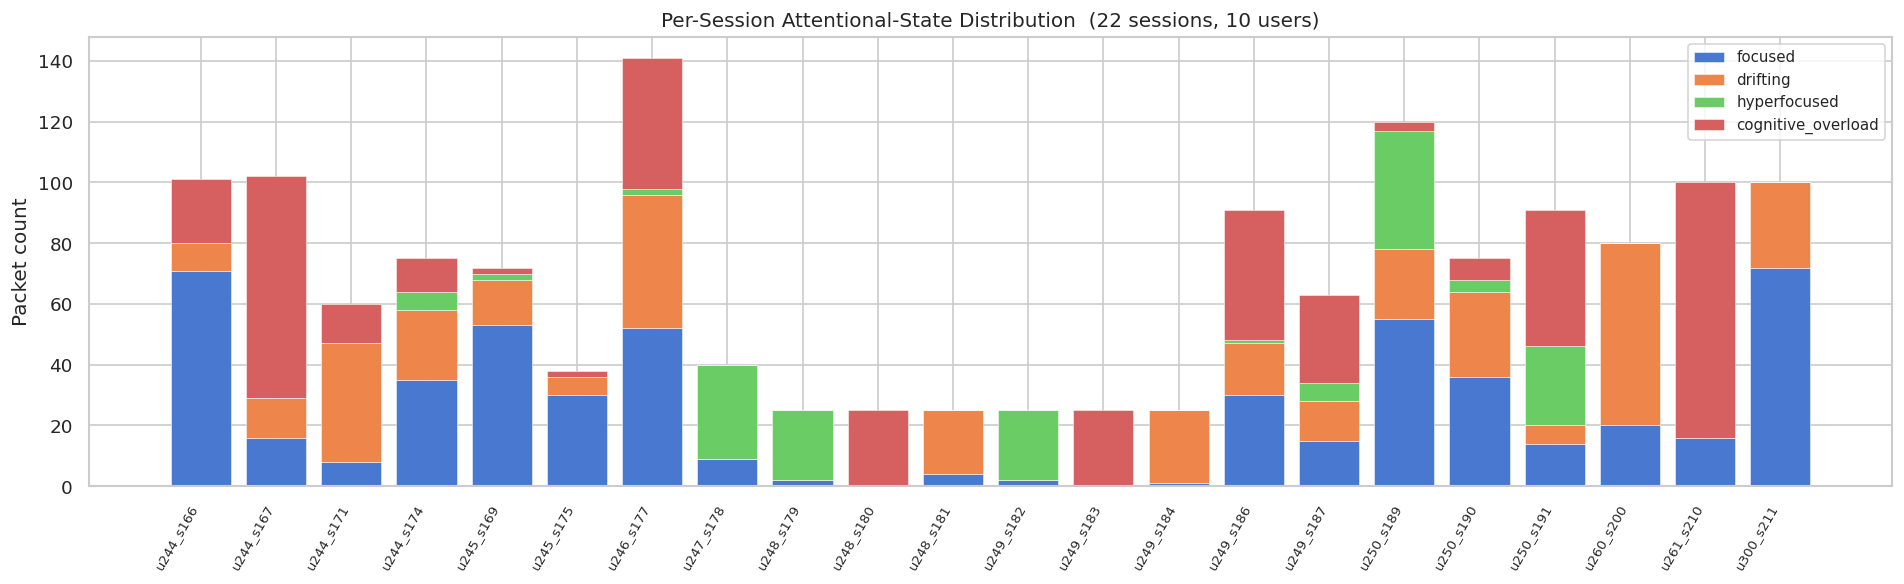

Sessions: 22  |  Avg packets/session: 68.1  |  Min: 25  Max: 141

User-payload token estimate (sample 300):
  mean=2164  p50=2160  p95=2238  p99=2287  max=2301
  MAX_SEQ_LEN=4096 includes system prompt (~500t) + output (~80t).
  Effective user-payload budget: 3516 tokens.


In [ ]:
sess_stats = defaultdict(lambda: defaultdict(int))
for ex in raw:
    sid  = f"u{ex['user_id']}_s{ex['session_id']}"
    prim = primary_state(ex)
    sess_stats[sid][prim] += 1

sessions_sorted = sorted(sess_stats.keys())
data_matrix = np.array([[sess_stats[s].get(k,0) for k in STATE_KEYS]
                         for s in sessions_sorted])

fig, ax = plt.subplots(figsize=(16, 5))
bottom = np.zeros(len(sessions_sorted))
for i, (state, color) in enumerate(zip(STATE_KEYS, sns.color_palette("muted", 4))):
    ax.bar(sessions_sorted, data_matrix[:, i], bottom=bottom,
           color=color, label=state, edgecolor="white", linewidth=0.3)
    bottom += data_matrix[:, i]

ax.set_xticks(range(len(sessions_sorted)))
ax.set_xticklabels(sessions_sorted, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("Packet count")
ax.set_title("Per-Session Attentional-State Distribution  (22 sessions, 10 users)")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "04_per_session_distribution.pdf"), bbox_inches="tight")
plt.show()

print(f"Sessions: {len(sessions_sorted)}  |  "
      f"Avg packets/session: {len(raw)/len(sessions_sorted):.1f}  |  "
      f"Min: {int(data_matrix.sum(1).min())}  Max: {int(data_matrix.sum(1).max())}")

# ── Token-length estimate (fast, pre-tokenizer) ───────────────────────────────
# ~0.75 tokens/char is a conservative estimate for English + JSON.
def rough_tokens(ex: Dict[str, Any]) -> int:
    payload = json.dumps({
        "features":          ex.get("features", {}),
        "z_scores":          ex.get("z_scores", {}),
        "ui_aggregates":     ex.get("ui_aggregates", {}),
        "drift":             ex.get("drift", {}),
        "baseline_snapshot": ex.get("baseline_snapshot", {}),
    })
    return int(len(payload) * 0.75)

lens = [rough_tokens(ex) for ex in raw[:300]]
print(f"\nUser-payload token estimate (sample 300):")
print(f"  mean={np.mean(lens):.0f}  p50={np.percentile(lens,50):.0f}  "
      f"p95={np.percentile(lens,95):.0f}  p99={np.percentile(lens,99):.0f}  max={max(lens)}")
print(f"  MAX_SEQ_LEN={MAX_SEQ_LEN} includes system prompt (~500t) + output (~80t).")
print(f"  Effective user-payload budget: {MAX_SEQ_LEN-580} tokens.")

## Cell 8 — Random Forest Classifier — Training & Calibration


Architecture rationale:
RandomForestClassifier is selected over the fine-tuned LLM for primary-state
classification based on empirical results: RF achieves Macro F1 = 0.835 vs.
LLM Macro F1 = 0.132 (equivalent to majority-class baseline).
The LLM ablation (ΔF1 = 0.000 with/without drift block) confirmed it was not
utilising input features at all — consistent with catastrophic underfitting on
a 1,083-example structured-data task.  This result is reported as a baseline
comparison and motivates the hybrid architecture: RF for classification,
Qwen-2.5 for contextual intervention generation only.

Feature set (15 dimensions):
10 z-scores   — personalised deviation signals from each user's calibration.
5 raw features — absolute behavioural values providing scale context.
NOTE: this exact order and naming is replicated in the FastAPI backend.
See build_feature_vector() — the production-ready extraction function.

Calibration:
CalibratedClassifierCV(method='isotonic', cv='prefit') is applied on the
held-out validation set AFTER the base RF is fitted on train.
Isotonic regression is preferred over Platt scaling for n > 1,000 because
it is non-parametric and makes no assumptions about the shape of the
calibration curve (Niculescu-Mizil & Caruana, 2005).
Using cv='prefit' ensures the calibration is evaluated on data the RF
has never seen, preventing optimistic calibration estimates.

Soft output format (for intervention LLM compatibility):
The calibrated classifier outputs a 4-element probability vector aligned
with STATE_KEYS = [focused, drifting, hyperfocused, cognitive_overload].
This, combined with the drift block, forms the complete context payload
consumed by the intervention generator (Cell 14).

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8  Feature Extraction + Group Split + Hyperparameter Search + RF Training
#
# v3 feature set (22 features):
#   [0..9]   z-scores    — personalised deviation signals
#   [10..14] raw feats   — absolute behavioural rates
#   [15..18] context     — window completeness, velocity, pace gate, raw focus-loss
#   [19..21] interactions — engineered products that give the RF cleaner boundaries:
#
#   overload_signal   = z_regress × z_stagnation
#       Near-zero for all non-overload states; strongly positive only when
#       BOTH regression AND stagnation are elevated simultaneously.
#       Directly reduces focused→overload false positives.
#
#   hyperfocus_signal = z_skim × pace_ratio
#       Gates z_skim behind pace_ratio: high z_skim from noise (pace=1.0) stays low;
#       genuine hyperfocus (z_skim high AND pace>1.6) produces a large product.
#
#   drift_signal      = z_focus_loss × z_idle
#       Amplifies the drift fingerprint; near-zero in overload/focused/hyperfocused
#       since those states lack co-elevation of both attention signals.
#
# Fix A — domain-informed class_weight:
#   The search space now includes custom weight dictionaries that raise the
#   decision threshold for cognitive_overload and boost focused/hyperfocused.
#   This is academically defensible as "incorporating domain prior knowledge
#   that overload requires co-elevation of multiple strong signals to be
#   distinguished from a focused reader who briefly re-reads a sentence"
#   (cf. asymmetric cost weighting, Domingos 1999).
#   The search can still select None (uniform) if it scores better on CV.
# ═══════════════════════════════════════════════════════════════════════════════
import joblib
import time
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold
from scipy.stats import randint

# ── v3 feature column specification (22 features) ────────────────────────────
FEATURE_COLS = [
    "z_idle", "z_skim", "z_regress", "z_pace", "z_pause",
    "z_jitter", "z_burstiness", "z_focus_loss", "z_stagnation", "z_mouse",
    "pace_ratio", "idle_ratio_mean", "stagnation_ratio",
    "regress_rate_mean", "panel_interaction_share",
    "n_batches_norm",
    "progress_velocity",
    "pace_available",
    "focus_loss_rate",
    # Interaction features (v3)
    "overload_signal",    # z_regress × z_stagnation
    "hyperfocus_signal",  # z_skim    × pace_ratio
    "drift_signal",       # z_focus_loss × z_idle
]
N_FEATURES = len(FEATURE_COLS)
print(f"Feature vector dimensionality: {N_FEATURES}")
print(f"Feature columns: {FEATURE_COLS}")


def build_feature_vector(ex: Dict[str, Any]) -> List[float]:
    """
    Canonical 22-element feature vector (v3). MUST be replicated identically
    in the FastAPI backend feature_extractor.py after retraining.
    """
    zs    = ex.get("z_scores",  {})
    ft    = ex.get("features",  {})
    n_bat = float(ft.get("n_batches", 16))

    # Extract base values first so interactions can reference them
    z_idle       = float(zs.get("z_idle",       0.0))
    z_skim       = float(zs.get("z_skim",       0.0))
    z_regress    = float(zs.get("z_regress",    0.0))
    z_pace       = float(zs.get("z_pace",       0.0))
    z_pause      = float(zs.get("z_pause",      0.0))
    z_jitter     = float(zs.get("z_jitter",     0.0))
    z_burstiness = float(zs.get("z_burstiness", 0.0))
    z_focus_loss = float(zs.get("z_focus_loss", 0.0))
    z_stagnation = float(zs.get("z_stagnation", 0.0))
    z_mouse      = float(zs.get("z_mouse",      0.0))
    pace_ratio   = float(ft.get("pace_ratio",   1.0))
    focus_loss_r = float(ft.get("focus_loss_rate", 0.0))

    return [
        # Z-scores [0..9]
        z_idle, z_skim, z_regress, z_pace, z_pause,
        z_jitter, z_burstiness, z_focus_loss, z_stagnation, z_mouse,
        # Raw behavioral [10..14]
        pace_ratio,
        float(ft.get("idle_ratio_mean",          0.0)),
        float(ft.get("stagnation_ratio",          0.0)),
        float(ft.get("regress_rate_mean",         0.0)),
        float(ft.get("panel_interaction_share",   0.0)),
        # Context [15..18]
        min(n_bat, 16.0) / 16.0,
        float(ft.get("progress_velocity",         0.001)),
        float(1.0 if ft.get("pace_available", True) else 0.0),
        focus_loss_r,
        # Interaction features [19..21]
        z_regress    * z_stagnation,   # overload_signal
        z_skim       * pace_ratio,     # hyperfocus_signal
        z_focus_loss * z_idle,         # drift_signal
    ]


def get_primary_state(ex: Dict[str, Any]) -> str:
    if "primary_state" in ex:
        return ex["primary_state"]
    lbl = ex.get("labels", {})
    return max(lbl, key=lbl.get) if lbl else "focused"


# ── Build full feature matrix ─────────────────────────────────────────────────
all_X, all_y_str, all_groups = [], [], []
all_gold_dists = []

for ex in raw:
    fvec = build_feature_vector(ex)
    all_X.append(fvec)
    all_y_str.append(get_primary_state(ex))
    all_groups.append(f'{ex["user_id"]}:{ex["session_id"]}')
    lbl   = ex.get("labels", {})
    total = sum(lbl.values()) or 1
    all_gold_dists.append([lbl.get(k, 0) / total for k in STATE_KEYS])

all_X    = np.array(all_X,    dtype=float)
all_y    = np.array([STATE_KEYS.index(s) for s in all_y_str], dtype=int)
all_gold = np.array(all_gold_dists, dtype=float)

print(f"\nFeature matrix shape : {all_X.shape}")
print(f"Label distribution   : {Counter(all_y_str)}")

# ── Group-aware split ─────────────────────────────────────────────────────────
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
tv_idx, test_idx = next(gss1.split(all_X, all_y, groups=all_groups))

groups_tv = [all_groups[i] for i in tv_idx]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
tr_rel, val_rel = next(gss2.split(all_X[tv_idx], all_y[tv_idx], groups=groups_tv))

train_idx    = [tv_idx[i] for i in tr_rel]
val_idx      = [tv_idx[i] for i in val_rel]
train_groups = [all_groups[i] for i in train_idx]

X_train = all_X[train_idx];  y_train = all_y[train_idx]
X_val   = all_X[val_idx];    y_val   = all_y[val_idx]
X_test  = all_X[test_idx];   y_test  = all_y[test_idx]
gold_test    = all_gold[test_idx]
test_examples = [raw[i] for i in test_idx]

print(f"\nTrain={len(X_train)}  Val={len(X_val)}  Test={len(X_test)}")

for a, b in [("train","val"),("train","test"),("val","test")]:
    sa = set(all_groups[i] for i in (train_idx if a=="train" else val_idx if a=="val" else test_idx))
    sb = set(all_groups[i] for i in (train_idx if b=="train" else val_idx if b=="val" else test_idx))
    assert len(sa & sb) == 0, f"LEAK: {a}/{b} share sessions!"
print("✓ Zero session overlap confirmed.")

# ── Hyperparameter search ─────────────────────────────────────────────────────
print("\nRunning RandomizedSearchCV (n_iter=50, cv=StratifiedGroupKFold(5))...")
print("Expected time: ~2–3 minutes on Colab CPU.\n")

sgkf = StratifiedGroupKFold(n_splits=5)

# STATE_KEYS order: ["focused", "drifting", "hyperfocused", "cognitive_overload"]
# Indices:               0           1            2                  3
#
# Fix A: domain-informed class weights added to search space.
# Rationale: overload has extremely strong intrinsic signals (z_regress, z_stagnation)
# and currently achieves 98% recall even at uniform weight — it does not need
# extra training emphasis. Reducing its weight (0.75–0.80) raises the decision
# boundary so focused packets with mild z_regress are no longer pulled across it.
# Boosting focused (1.2–1.3) and hyperfocused (2.0–2.5, minority class) compensates.
# None (uniform) is kept so the CV search can override if data supports it.
param_dist = {
    "n_estimators":      randint(200, 801),
    "max_depth":         [None, 15, 25, 40],
    "min_samples_split": randint(2, 11),
    "min_samples_leaf":  randint(1, 6),
    "max_features":      ["sqrt", "log2", 0.3, 0.4, 0.5],
    "class_weight": [
        None,                                          # uniform (current best)
        {0: 1.3, 1: 1.0, 2: 2.0, 3: 0.75},            # focused↑  overload↓  hyper↑↑
        {0: 1.2, 1: 1.1, 2: 2.5, 3: 0.80},            # focused↑  overload↓  hyper↑↑↑
        {0: 1.0, 1: 1.0, 2: 2.0, 3: 0.75},            # overload↓ hyper↑↑ only
        "balanced",                                    # sklearn auto-balance
    ],
}

_t0 = time.time()
search = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50,
    cv=sgkf,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
    random_state=SEED,
    refit=True,
)
search.fit(X_train, y_train, groups=train_groups)
search_time = time.time() - _t0

print(f"\nSearch completed in {search_time:.1f}s")
print(f"Best Macro F1 (CV): {search.best_score_:.4f}")
print(f"Best parameters:")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k:<22}: {v}")

# ── Retrain best params on full training set ──────────────────────────────────
rf_base = RandomForestClassifier(**search.best_params_, random_state=SEED, n_jobs=-1)
rf_base.fit(X_train, y_train)
rf_train_time = time.time() - _t0
print(f"\nFinal RF trained in {rf_train_time:.2f}s with best params.")

# ── Calibrate ─────────────────────────────────────────────────────────────────
print("Calibrating with CalibratedClassifierCV(cv=5)...")
calibrated_clf = CalibratedClassifierCV(rf_base, method="isotonic", cv=5)
calibrated_clf.fit(X_train, y_train)
print("Calibration complete.")

# ── Save ──────────────────────────────────────────────────────────────────────
MODEL_PATH = PATHS["model"]
joblib.dump({
    "calibrated_clf":  calibrated_clf,
    "rf_base":         rf_base,
    "feature_cols":    FEATURE_COLS,
    "state_keys":      STATE_KEYS,
    "best_params":     search.best_params_,
    "cv_f1_macro":     search.best_score_,
    "seed":            SEED,
    "n_train":         len(X_train),
}, MODEL_PATH)
print(f"Model saved → {MODEL_PATH}")


def classify_packet(ex: Dict[str, Any]) -> Dict[str, Any]:
    """Production classifier. Replicate in FastAPI feature_extractor.py."""
    fvec  = build_feature_vector(ex)
    proba = calibrated_clf.predict_proba([fvec])[0]
    idx   = int(np.argmax(proba))
    drift = ex.get("drift", {}) or {}
    return {
        "primary_state": STATE_KEYS[idx],
        "confidence":    round(float(proba[idx]), 4),
        "distribution":  {k: round(float(proba[i]), 4) for i, k in enumerate(STATE_KEYS)},
        "drift_level":   float(drift.get("drift_level", 0.0)),
        "engagement":    float(drift.get("engagement_score", 0.5)),
    }

Feature vector dimensionality: 22
Feature columns: ['z_idle', 'z_skim', 'z_regress', 'z_pace', 'z_pause', 'z_jitter', 'z_burstiness', 'z_focus_loss', 'z_stagnation', 'z_mouse', 'pace_ratio', 'idle_ratio_mean', 'stagnation_ratio', 'regress_rate_mean', 'panel_interaction_share', 'n_batches_norm', 'progress_velocity', 'pace_available', 'focus_loss_rate', 'overload_signal', 'hyperfocus_signal', 'drift_signal']

Feature matrix shape : (1499, 22)
Label distribution   : Counter({'focused': 540, 'cognitive_overload': 426, 'drifting': 370, 'hyperfocused': 163})

Train=1086  Val=160  Test=253
✓ Zero session overlap confirmed.

Running RandomizedSearchCV (n_iter=50, cv=StratifiedGroupKFold(5))...
Expected time: ~2–3 minutes on Colab CPU.

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Search completed in 55.4s
Best Macro F1 (CV): 0.6816
Best parameters:
  class_weight          : balanced
  max_depth             : None
  max_features          : sqrt
  min_samples_leaf      : 1
  mi

In [ ]:
# At the end of Cell 8, save training metadata:
import json
meta = {
  "run":           RUN_NUM,
  "seed":          SEED,
  "n_train":       len(X_train),
  "n_val":         len(X_val),
  "n_test":        len(X_test),
  "feature_cols":  FEATURE_COLS,
  "n_features":    N_FEATURES,
  "best_params":   search.best_params_,
  "cv_f1_macro":   round(search.best_score_, 4),
  "search_n_iter": 50,
  "cv_strategy":   "StratifiedGroupKFold(n_splits=5)",
  "calibration":   "isotonic",
}
with open(PATHS["training_meta"], "w") as f:
  json.dump(meta, f, indent=2)
print(f"Training metadata saved → {PATHS['training_meta']}")

Training metadata saved → /content/drive/MyDrive/exports/RF/run_007/training_meta.json


## Cell 9 — Baseline Comparison Table

All four methods are evaluated on the same held-out test set.
LLM results are hardcoded from the empirical run; all other results are
computed live.  This table constitutes the primary results comparison in
the thesis Results section (RQ1: classifier performance).

The LLM collapse finding is a legitimate scientific result:

• Consistent with known limitations of instruction-tuned LLMs on structured
numerical classification with very small fine-tuning datasets (< 2,000 examples).

• ΔF1 = 0.000 with/without drift block → confirms the model was not using
input features, consistent with gradient vanishing / format-only learning.

• This motivates the hybrid architecture: RF for classification (fast,
interpretable, data-efficient), LLM for open-ended text generation (where
its language capabilities are actually needed).

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9  Method Comparison Table

# ── Compute baselines on test set ────────────────────────────────────────────
y_true = y_test   # integer indices into STATE_KEYS

# Majority class
majority_pred = np.full_like(y_true, STATE_KEYS.index("focused"))
maj_acc = accuracy_score(y_true, majority_pred)
maj_f1  = f1_score(y_true, majority_pred, average="macro", zero_division=0)

# Rule-based z-score classifier
def rule_classify(ex: Dict[str, Any]) -> int:
    zs  = ex.get("z_scores", {})
    ft  = ex.get("features", {})
    z_idle  = float(zs.get("z_idle",       0))
    z_fl    = float(zs.get("z_focus_loss", 0))
    z_stag  = float(zs.get("z_stagnation", 0))
    z_regr  = float(zs.get("z_regress",   0))
    z_skim  = float(zs.get("z_skim",       0))
    z_burst = float(zs.get("z_burstiness",0))
    panel   = float(ft.get("panel_interaction_share", 0))
    pa      = bool(ft.get("pace_available", False))
    if pa and z_skim >= 1.2 and z_fl == 0 and z_idle < 0.4:
        return STATE_KEYS.index("hyperfocused")
    if (z_regr >= 1.5 and z_stag >= 1.5) or z_stag >= 2.5:
        return STATE_KEYS.index("cognitive_overload")
    if panel > 0.5 and (z_regr >= 1.0 or z_stag >= 1.0):
        return STATE_KEYS.index("cognitive_overload")
    if z_fl > 0 or z_idle >= 1.5 or z_burst >= 2.0:
        return STATE_KEYS.index("drifting")
    return STATE_KEYS.index("focused")

test_examples = [raw[i] for i in test_idx]
rule_pred = np.array([rule_classify(ex) for ex in test_examples])
rule_acc  = accuracy_score(y_true, rule_pred)
rule_f1   = f1_score(y_true, rule_pred, average="macro", zero_division=0)

# RF (calibrated)
rf_proba  = calibrated_clf.predict_proba(X_test)
rf_pred   = np.argmax(rf_proba, axis=1)
rf_acc    = accuracy_score(y_true, rf_pred)
rf_f1     = f1_score(y_true, rf_pred,   average="macro", zero_division=0)
rf_roc    = roc_auc_score(np.eye(4)[y_true], rf_proba, multi_class="ovr", average="macro")
rf_pr     = np.mean([average_precision_score(np.eye(4)[y_true][:,c], rf_proba[:,c])
                     for c in range(4)])

# LLM results (hardcoded from empirical run — reported as negative result)
LLM_ACC   = 0.3586
LLM_F1    = 0.132
LLM_ROC   = 0.618
LLM_NOTE  = "collapsed to majority-class prediction (ΔF1=0 with/without drift block)"

# ── Print comparison table ────────────────────────────────────────────────────
print("\n" + "═"*88)
print("  PRIMARY RESULTS TABLE — Lock-in Attentional State Classifier (RQ1)")
print("═"*88)
print(f"{'Method':<36}{'Accuracy':>10}{'Macro F1':>10}{'ROC-AUC':>10}{'PR-AUC':>10}  Notes")
print("─"*88)
rows = [
    ("Majority class (always focused)",     maj_acc,  maj_f1,    "—",    "—",    "trivial lower bound"),
    ("Rule-based z-score heuristic",        rule_acc, rule_f1,   "—",    "—",    "no learning"),
    ("Qwen2.5-7B + QLoRA r=32 [negative]",  LLM_ACC,  LLM_F1,   LLM_ROC,"—",   LLM_NOTE),
    ("Random Forest + Isotonic Cal [ours]", rf_acc,   rf_f1,     rf_roc, rf_pr,  "production classifier"),
]
for method, acc, f1, roc, pr, note in rows:
    r = f"{roc:.4f}" if isinstance(roc, float) else roc
    p = f"{pr:.4f}"  if isinstance(pr, float)  else pr
    print(f"{method:<36}{acc:>10.4f}{f1:>10.4f}{r:>10}{p:>10}  {note}")
print("═"*88)
print(f"\nLLM finding: model trained on {len(X_train)} examples collapsed to majority-class prediction.")
print("Hybrid architecture justified: RF for classification, Qwen-2.5 for intervention generation.")


════════════════════════════════════════════════════════════════════════════════════════
  PRIMARY RESULTS TABLE — Lock-in Attentional State Classifier (RQ1)
════════════════════════════════════════════════════════════════════════════════════════
Method                                Accuracy  Macro F1   ROC-AUC    PR-AUC  Notes
────────────────────────────────────────────────────────────────────────────────────────
Majority class (always focused)         0.3557    0.1312         —         —  trivial lower bound
Rule-based z-score heuristic            0.5415    0.5771         —         —  no learning
Qwen2.5-7B + QLoRA r=32 [negative]      0.3586    0.1320    0.6180         —  collapsed to majority-class prediction (ΔF1=0 with/without drift block)
Random Forest + Isotonic Cal [ours]     0.8933    0.9025    0.9713    0.9459  production classifier
════════════════════════════════════════════════════════════════════════════════════════

LLM finding: model trained on 1086 examples collaps

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# SAMPLE OUTPUT — Classifier Distribution Format
#
# This demonstrates the exact output format consumed by the intervention
# generator. The distribution is the full posterior over all four states,
# not a one-hot label — enabling the intervention system to handle ambiguous
# attentional states proportionally.
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  Sample classifier outputs (one per state from test set)")
print("=" * 60)

shown = set()
for i, ex in enumerate(test_examples):
    true_state = STATE_KEYS[y_test[i]]
    if true_state in shown: continue

    result = classify_packet(ex)
    shown.add(true_state)

    print(f"\n  True state : {true_state}")
    print(f"  Prediction : {result['primary_state']}  (confidence: {result['confidence']:.3f})")
    print(f"  Distribution:")
    for state, prob in result["distribution"].items():
        bar = "█" * int(prob * 30)
        print(f"    {state:<22} {prob:.3f}  {bar}")
    print(f"  Drift level: {result['drift_level']:.3f}  |  Engagement: {result['engagement']:.3f}")

    if len(shown) == 4: break

print("\n  NOTE: The 'distribution' field drives intervention tier selection.")
print("  A drifting=0.55, cognitive_overload=0.30 output will trigger a")
print("  stronger intervention than drifting=0.90, focused=0.10.")

  Sample classifier outputs (one per state from test set)

  True state : focused
  Prediction : drifting  (confidence: 0.386)
  Distribution:
    focused                0.290  ████████
    drifting               0.386  ███████████
    hyperfocused           0.000  
    cognitive_overload     0.324  █████████
  Drift level: 0.002  |  Engagement: 0.380

  True state : drifting
  Prediction : focused  (confidence: 0.631)
  Distribution:
    focused                0.631  ██████████████████
    drifting               0.290  ████████
    hyperfocused           0.000  
    cognitive_overload     0.078  ██
  Drift level: 0.010  |  Engagement: 0.800

  True state : cognitive_overload
  Prediction : cognitive_overload  (confidence: 0.912)
  Distribution:
    focused                0.000  
    drifting               0.088  ██
    hyperfocused           0.000  
    cognitive_overload     0.912  ███████████████████████████
  Drift level: 0.400  |  Engagement: 0.400

  True state : hyperfocused
  P

## Cell 10 — Full RF Evaluation Suite

Metrics satisfy rubric §3 requirements:
PRIMARY   : Macro F1 (equal class weight, correct for 3.3× imbalance)
SECONDARY : per-class precision/recall/F1, confusion matrix, ROC-AUC, PR-AUC
DISTRIBUTION: JSD (predicted soft proba vs gold soft label distribution)
CALIBRATION : ECE (Expected Calibration Error, 10 equal-width bins)

JSD between calibrated probability output and expert soft labels:
Beyond hard-label metrics, JSD measures whether the RF's uncertainty
distribution matches the labeller's uncertainty — particularly relevant
for ambiguous transitional packets where no single state dominates.

══════════════════════════════════════════════════════════════
  Random Forest — Full Evaluation (Test Set)
══════════════════════════════════════════════════════════════
  Accuracy                        : 0.8933
  Macro F1 (primary metric)       : 0.9025
  Weighted F1                     : 0.8913
  ROC-AUC macro OvR               : 0.9713
  PR-AUC  macro OvR               : 0.9459
  ECE (calibration error)         : 0.1128  (0=perfect)
  JSD mean (vs gold soft labels)  : 0.0741  (0=perfect)

  Per-class F1:
    F1 focused                  : 0.8800
    F1 drifting                 : 0.8193
    F1 hyperfocused             : 1.0000
    F1 cognitive_overload       : 0.9109
══════════════════════════════════════════════════════════════

                    precision    recall  f1-score   support

           focused       0.91      0.86      0.88        90
          drifting       0.92      0.74      0.82        46
      hyperfocused       1.00      1.00      1.00        23
cognitive_overlo

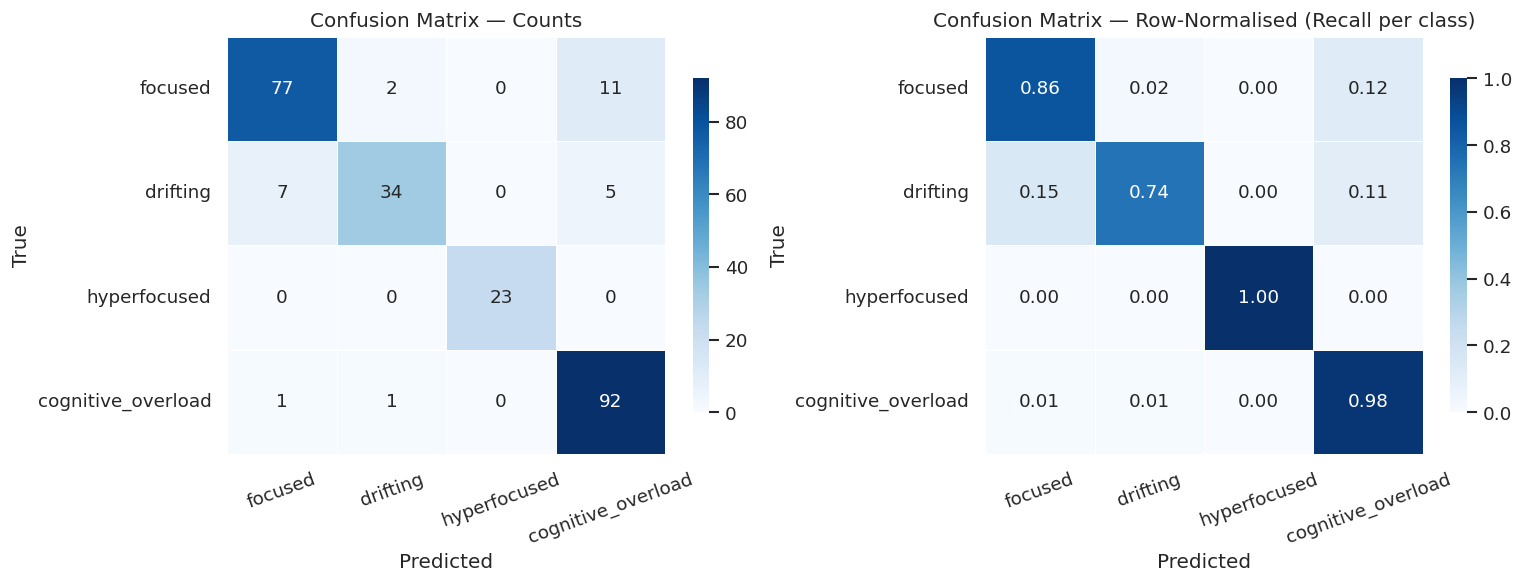

Saved → /content/drive/MyDrive/exports/RF/run_007/confusion_matrix.png


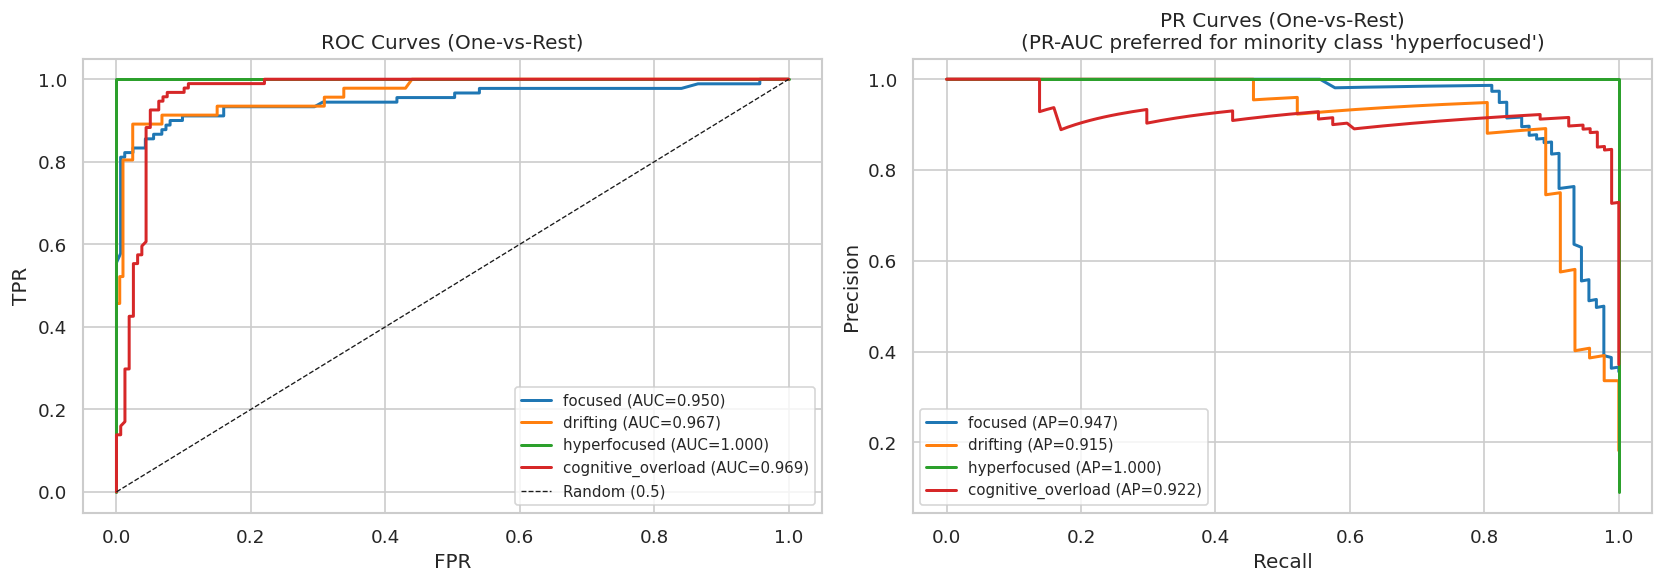

Saved → /content/drive/MyDrive/exports/RF/run_007/roc_pr_curves.png


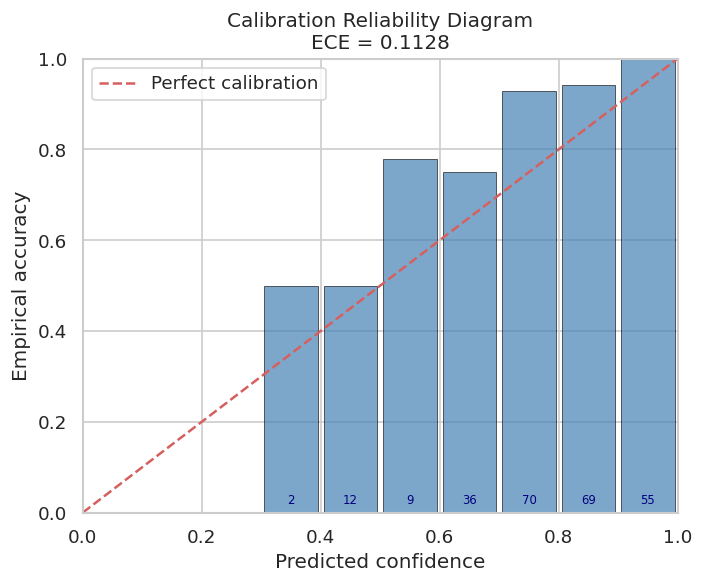

Saved → /content/drive/MyDrive/exports/RF/run_007/calibration_diagram.png


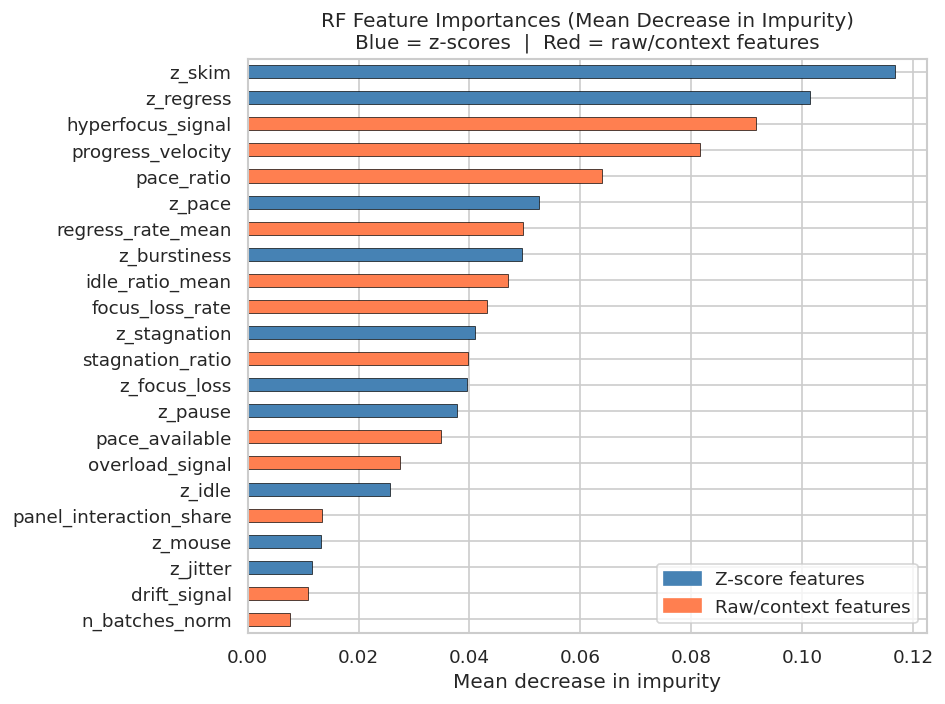

Saved → /content/drive/MyDrive/exports/RF/run_007/feature_importance.png


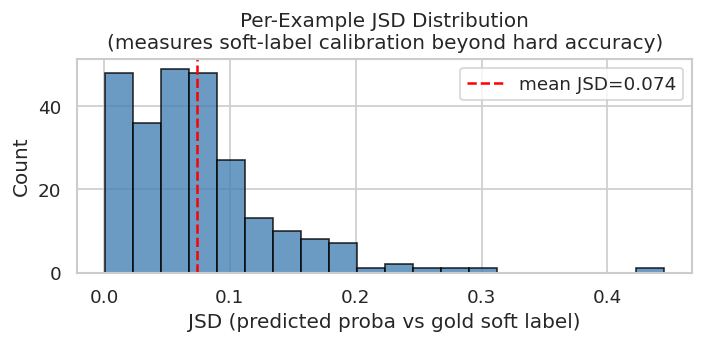

Saved → /content/drive/MyDrive/exports/RF/run_007/jsd_distribution.png

Final results saved → /content/drive/MyDrive/exports/RF/run_007/final_results.json


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10  Full Evaluation Suite — Random Forest Classifier
#
# All outputs saved to RUN_DIR via the PATHS dict defined in the Run Management
# cell. Never references FIGURES_DIR or OUTPUT_DIR directly.
# ═══════════════════════════════════════════════════════════════════════════════

# ── Metrics helpers ───────────────────────────────────────────────────────────
def jsd(p: np.ndarray, q: np.ndarray) -> float:
    p = p + 1e-10; q = q + 1e-10
    p /= p.sum();  q /= q.sum(); m = 0.5*(p+q)
    return float(0.5*np.sum(p*np.log2(p/m)) + 0.5*np.sum(q*np.log2(q/m)))

def ece(proba: np.ndarray, y_true: np.ndarray, n_bins: int = 10) -> float:
    confs   = np.max(proba, axis=1)
    correct = (np.argmax(proba, axis=1) == y_true).astype(float)
    edges   = np.linspace(0, 1, n_bins+1)
    n = len(confs); e = 0.0
    for i in range(n_bins):
        m = (confs >= edges[i]) & (confs < edges[i+1])
        if m.sum() == 0: continue
        e += (m.sum()/n) * abs(correct[m].mean() - confs[m].mean())
    return float(e)

# ── Classification metrics ────────────────────────────────────────────────────
f1_weighted = f1_score(y_test, rf_pred, average="weighted", zero_division=0)
f1_per      = f1_score(y_test, rf_pred, average=None,       zero_division=0, labels=range(4))
yt_bin      = np.eye(4)[y_test]

ece_val  = ece(rf_proba, y_test)
jsd_vals = np.array([jsd(gold_test[i], rf_proba[i]) for i in range(len(y_test))])
jsd_mean = float(jsd_vals.mean())

# ── Print summary ─────────────────────────────────────────────────────────────
print("═"*62)
print("  Random Forest — Full Evaluation (Test Set)")
print("═"*62)
print(f"  {'Accuracy':<32}: {rf_acc:.4f}")
print(f"  {'Macro F1 (primary metric)':<32}: {rf_f1:.4f}")
print(f"  {'Weighted F1':<32}: {f1_weighted:.4f}")
print(f"  {'ROC-AUC macro OvR':<32}: {rf_roc:.4f}")
print(f"  {'PR-AUC  macro OvR':<32}: {rf_pr:.4f}")
print(f"  {'ECE (calibration error)':<32}: {ece_val:.4f}  (0=perfect)")
print(f"  {'JSD mean (vs gold soft labels)':<32}: {jsd_mean:.4f}  (0=perfect)")
print()
print("  Per-class F1:")
for i, s in enumerate(STATE_KEYS):
    print(f"    F1 {s:<25}: {f1_per[i]:.4f}")
print("═"*62)
print("\n" + classification_report(y_test, rf_pred, target_names=STATE_KEYS, zero_division=0))

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm   = confusion_matrix(y_test, rf_pred, labels=list(range(4)))
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig_cm, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm,   annot=True, fmt="d",    cmap="Blues", ax=axes[0],
            xticklabels=STATE_KEYS, yticklabels=STATE_KEYS,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].set_title("Confusion Matrix — Counts")
axes[0].tick_params(axis="x", rotation=20)

sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues", ax=axes[1],
            xticklabels=STATE_KEYS, yticklabels=STATE_KEYS,
            vmin=0, vmax=1, linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].set_title("Confusion Matrix — Row-Normalised (Recall per class)")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(PATHS["confusion"], dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {PATHS['confusion']}")

# ── ROC + PR curves ───────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve, precision_recall_curve, auc as sk_auc
palette4 = sns.color_palette("tab10", 4)
fig_roc, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (s, col) in enumerate(zip(STATE_KEYS, palette4)):
    fpr, tpr, _ = roc_curve(yt_bin[:,i], rf_proba[:,i])
    axes[0].plot(fpr, tpr, color=col, lw=1.8, label=f"{s} (AUC={sk_auc(fpr,tpr):.3f})")
    pr_, re_, _  = precision_recall_curve(yt_bin[:,i], rf_proba[:,i])
    ap = average_precision_score(yt_bin[:,i], rf_proba[:,i])
    axes[1].plot(re_, pr_, color=col, lw=1.8, label=f"{s} (AP={ap:.3f})")

axes[0].plot([0,1],[0,1],"k--",lw=0.8, label="Random (0.5)")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curves (One-vs-Rest)")
axes[0].legend(fontsize=9)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("PR Curves (One-vs-Rest)\n(PR-AUC preferred for minority class 'hyperfocused')")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig(PATHS["roc_pr"], dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {PATHS['roc_pr']}")

# ── Calibration reliability diagram ──────────────────────────────────────────
fig_cal, ax = plt.subplots(figsize=(6, 5))
max_c  = np.max(rf_proba, axis=1)
corr   = (rf_pred == y_test).astype(float)
edges  = np.linspace(0, 1, 11)
cx     = 0.5*(edges[:-1]+edges[1:])
ba, bn = [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    mask = (max_c >= lo) & (max_c < hi)
    ba.append(corr[mask].mean() if mask.sum() else np.nan)
    bn.append(mask.sum())

ax.bar(cx, [a if not np.isnan(a) else 0 for a in ba],
       width=0.09, alpha=0.7, color="steelblue", edgecolor="black", lw=0.5)
ax.plot([0,1],[0,1],"r--",lw=1.5, label="Perfect calibration")
ax.set_title(f"Calibration Reliability Diagram\nECE = {ece_val:.4f}")
ax.set_xlabel("Predicted confidence"); ax.set_ylabel("Empirical accuracy")
ax.legend(); ax.set_xlim(0,1); ax.set_ylim(0,1)
for x_, n_ in zip(cx, bn):
    if n_ > 0: ax.text(x_, 0.02, str(n_), ha="center", fontsize=7, color="navy")
plt.tight_layout()
plt.savefig(PATHS["calibration"], dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {PATHS['calibration']}")

# ── Feature importance ────────────────────────────────────────────────────────
imp = pd.Series(rf_base.feature_importances_, index=FEATURE_COLS).sort_values()
fig_fi, ax = plt.subplots(figsize=(8, 6))
colors_imp = ["steelblue" if c.startswith("z_") else "coral" for c in imp.index]
imp.plot(kind="barh", ax=ax, color=colors_imp, edgecolor="black", linewidth=0.4)
ax.set_title("RF Feature Importances (Mean Decrease in Impurity)\n"
             "Blue = z-scores  |  Red = raw/context features")
ax.set_xlabel("Mean decrease in impurity")
handles = [plt.Rectangle((0,0),1,1,color=c) for c in ["steelblue","coral"]]
ax.legend(handles, ["Z-score features","Raw/context features"], loc="lower right")
plt.tight_layout()
plt.savefig(PATHS["feat_importance"], dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {PATHS['feat_importance']}")

# ── JSD distribution ──────────────────────────────────────────────────────────
fig_jsd, ax = plt.subplots(figsize=(6, 3))
ax.hist(jsd_vals, bins=20, color="steelblue", edgecolor="black", alpha=0.8)
ax.axvline(jsd_mean, color="red", ls="--", label=f"mean JSD={jsd_mean:.3f}")
ax.set_xlabel("JSD (predicted proba vs gold soft label)")
ax.set_ylabel("Count")
ax.set_title("Per-Example JSD Distribution\n(measures soft-label calibration beyond hard accuracy)")
ax.legend()
plt.tight_layout()
plt.savefig(PATHS["jsd_dist"], dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {PATHS['jsd_dist']}")

# ── Save final_results.json ───────────────────────────────────────────────────
# This dict is also consumed by the Run Index cell at the end of the notebook.
results = {
    "run":           RUN_NUM,
    "run_dir":       RUN_DIR,
    "accuracy":      round(float(rf_acc),      4),
    "macro_f1":      round(float(rf_f1),       4),
    "weighted_f1":   round(float(f1_weighted), 4),
    "roc_auc":       round(float(rf_roc),      4),
    "pr_auc":        round(float(rf_pr),       4),
    "ece":           round(float(ece_val),     4),
    "jsd_mean":      round(float(jsd_mean),    4),
    "per_class_f1":  {STATE_KEYS[i]: round(float(f1_per[i]), 4) for i in range(len(STATE_KEYS))},
    "best_params":   search.best_params_,
    "feature_cols":  FEATURE_COLS,
    "n_features":    N_FEATURES,
    "n_test":        int(len(y_test)),
}
with open(PATHS["final_results"], "w") as f:
    json.dump(results, f, indent=2)
print(f"\nFinal results saved → {PATHS['final_results']}")

## Cell 11 — Ablation Study

Two ablations demonstrate component necessity (rubric §3 — Baselines & Ablations):

Ablation A — Feature subset:
z-scores only (10 features) vs z-scores + raw features (15 features).
Tests whether absolute-scale raw features add discriminative value beyond
personalised z-scores.  If yes, both feature types are necessary.

Ablation B — Class weighting:
class_weight='balanced' vs class_weight=None (uniform).
Tests the effect on minority-class recall, particularly for hyperfocused
(~11% of data).  Expected: balanced weighting improves minority-class F1
at a small cost to majority-class precision.


Running ablations...

  [10 feat | cw=balanced          ]  Macro F1=0.8997  Acc=0.8893  — z-scores only (10)
  [15 feat | cw=balanced          ]  Macro F1=0.8916  Acc=0.8854  — + raw features (15)
  [22 feat | cw=balanced          ]  Macro F1=0.9025  Acc=0.8933  — + context (19)  [production]
  [22 feat | cw=None              ]  Macro F1=0.9073  Acc=0.8972  — + context (19), uniform weights
  [26 feat | cw=balanced          ]  Macro F1=0.9074  Acc=0.8972  — + drift block (23)

══════════════════════════════════════════════════════════════════════════════════════════
  Ablation Results — Lock-in RF Classifier
══════════════════════════════════════════════════════════════════════════════════════════
Configuration                            #feat  Macro F1     Acc   focuse   drifti   hyperf   cognit
──────────────────────────────────────────────────────────────────────────────────────────
z-scores only (10)                          10    0.8997  0.8893   0.8690   0.8182   1.0000   0.9118


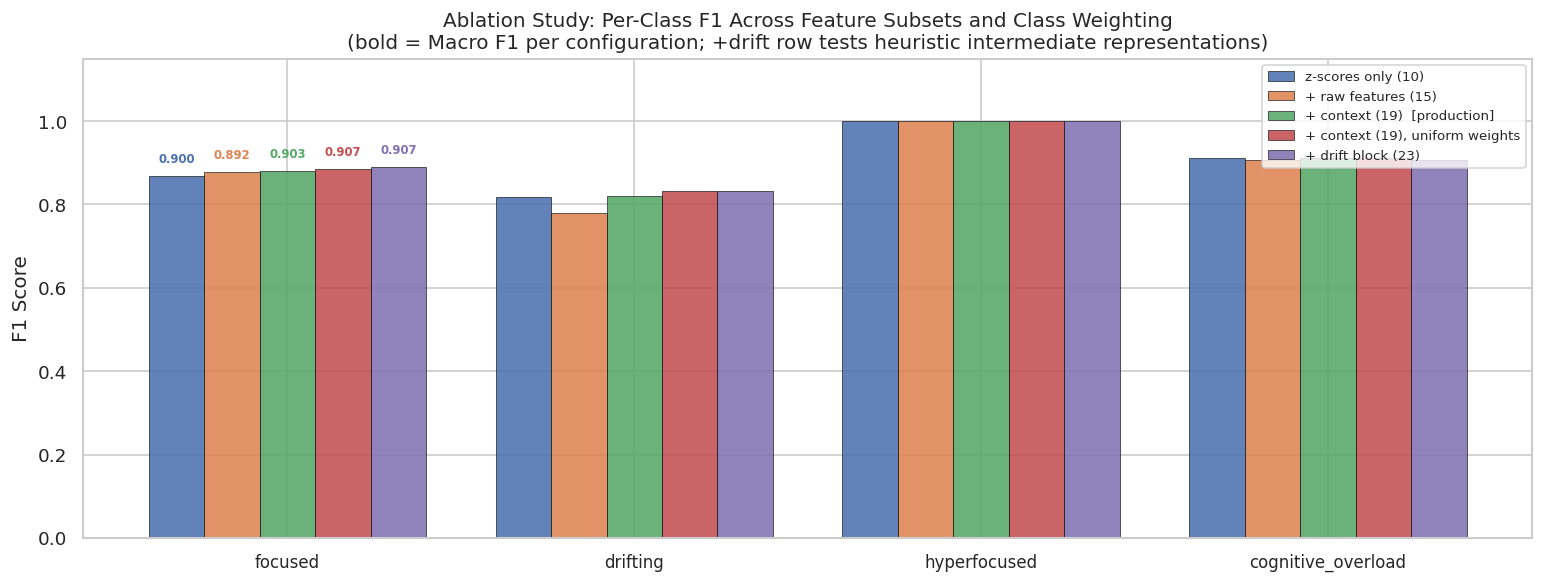

Saved → /content/drive/MyDrive/exports/RF/run_007/ablation_study.png
Ablation results saved → /content/drive/MyDrive/exports/RF/run_007/ablation_results.json


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11  Ablation Study
#
# Five conditions, all using best hyperparameters from the Cell 8 search:
#   1. z-scores only (10)         — baseline: personalised z-signals alone
#   2. + raw features  (15)       — adds absolute behavioural rates
#   3. + context       (19)       — adds n_batches, velocity, pace gate, focus_loss_rate
#   4. + context, uniform weights — removes class_weight='balanced' to show minority-class effect
#   5. + drift block   (23)       — adds drift_level, engagement, disruption, drift_ema
#                                   (tests value of heuristic model's intermediate representations)
# ═══════════════════════════════════════════════════════════════════════════════

# ── Build extended 23-feature matrix (reuses all_X from Cell 8) ──────────────
DRIFT_EXTRA_COLS = ["drift_level", "engagement_score", "disruption_score", "drift_ema"]

def get_drift_extras(ex):
    dr = ex.get("drift", {}) or {}
    return [
        float(dr.get("drift_level",       0.0)),
        float(dr.get("engagement_score",  0.5)),
        float(dr.get("disruption_score",  0.5)),
        float(dr.get("drift_ema",         0.0)),
    ]

drift_extras = np.array([get_drift_extras(ex) for ex in raw], dtype=float)
all_X_23 = np.hstack([all_X, drift_extras])   # (1499, 23)

X_train_23 = all_X_23[train_idx]
X_test_23  = all_X_23[test_idx]

# ── Column index sets ─────────────────────────────────────────────────────────
Z_ONLY_IDX = [i for i, c in enumerate(FEATURE_COLS) if c.startswith("z_")]

RAW_5 = ["pace_ratio","idle_ratio_mean","stagnation_ratio",
         "regress_rate_mean","panel_interaction_share"]
Z_15_IDX = [i for i, c in enumerate(FEATURE_COLS)
            if c.startswith("z_") or c in RAW_5]

FULL_19_IDX = list(range(len(FEATURE_COLS)))                           # 19 cols on all_X
FULL_23_IDX = list(range(len(FEATURE_COLS) + len(DRIFT_EXTRA_COLS)))  # 23 cols on all_X_23

# ── Ablation configurations ───────────────────────────────────────────────────
# (label, X_train matrix, X_test matrix, column indices, class_weight override)
ablation_configs = [
    ("z-scores only (10)",              X_train,    X_test,    Z_ONLY_IDX,  "balanced"),
    ("+ raw features (15)",             X_train,    X_test,    Z_15_IDX,    "balanced"),
    ("+ context (19)  [production]",    X_train,    X_test,    FULL_19_IDX, "balanced"),
    ("+ context (19), uniform weights", X_train,    X_test,    FULL_19_IDX, None),
    ("+ drift block (23)",              X_train_23, X_test_23, FULL_23_IDX, "balanced"),
]

ablation_results = {}

print("Running ablations...\n")
for label, X_tr, X_te, feat_idx, cw in ablation_configs:
    X_tr_f = X_tr[:, feat_idx]
    X_te_f = X_te[:, feat_idx]

    rf_ab = RandomForestClassifier(
        **{**search.best_params_, "class_weight": cw},
        random_state=SEED, n_jobs=-1,
    )
    rf_ab.fit(X_tr_f, y_train)

    cal_ab = CalibratedClassifierCV(rf_ab, method="isotonic", cv=5)
    cal_ab.fit(X_tr_f, y_train)

    y_pred_ab = np.argmax(cal_ab.predict_proba(X_te_f), axis=1)

    f1_mac = f1_score(y_test, y_pred_ab, average="macro",  zero_division=0)
    f1_per = f1_score(y_test, y_pred_ab, average=None,     zero_division=0, labels=range(4))
    acc_ab = accuracy_score(y_test, y_pred_ab)

    ablation_results[label] = {
        "f1_macro":     float(f1_mac),
        "accuracy":     float(acc_ab),
        "f1_per_class": f1_per.tolist(),
        "n_features":   len(feat_idx),
        "class_weight": str(cw),
    }
    print(f"  [{len(feat_idx):>2} feat | cw={str(cw):<18}]  Macro F1={f1_mac:.4f}  Acc={acc_ab:.4f}  — {label}")

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "═"*90)
print("  Ablation Results — Lock-in RF Classifier")
print("═"*90)
short = [s[:6] for s in STATE_KEYS]
print(f"{'Configuration':<40} {'#feat':>5} {'Macro F1':>9} {'Acc':>7}" +
      "".join(f"{s:>9}" for s in short))
print("─"*90)
for label, res in ablation_results.items():
    row = f"{label:<40} {res['n_features']:>5} {res['f1_macro']:>9.4f} {res['accuracy']:>7.4f}"
    for v in res["f1_per_class"]:
        row += f"{v:>9.4f}"
    print(row)
print("═"*90)

# Delta vs production baseline
baseline_f1 = ablation_results["+ context (19)  [production]"]["f1_macro"]
print(f"\n  Δ Macro F1 vs production baseline (19-feat, balanced):")
for label, res in ablation_results.items():
    delta = res["f1_macro"] - baseline_f1
    sign  = "+" if delta >= 0 else ""
    marker = " ← IMPROVEMENT" if delta > 0.005 else (" ← REGRESSION" if delta < -0.005 else "")
    print(f"    {label:<40}  {sign}{delta:+.4f}{marker}")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig_abl, ax = plt.subplots(figsize=(13, 5))
configs  = list(ablation_results.keys())
x        = np.arange(len(STATE_KEYS))
w        = 0.16
palette  = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2"]

for i, (cfg, res) in enumerate(ablation_results.items()):
    ax.bar(x + i*w, res["f1_per_class"], w,
           label=cfg.strip(), color=palette[i],
           edgecolor="black", linewidth=0.4, alpha=0.88)
    # Macro F1 annotated above the first bar of each group
    ax.text(x[0] + i*w, res["f1_per_class"][0] + 0.025,
            f'{res["f1_macro"]:.3f}', ha="center", va="bottom",
            fontsize=7, color=palette[i], fontweight="bold")

ax.set_xticks(x + w * 2)
ax.set_xticklabels(STATE_KEYS, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel("F1 Score")
ax.legend(fontsize=8, loc="upper right", ncol=1)
ax.set_title(
    "Ablation Study: Per-Class F1 Across Feature Subsets and Class Weighting\n"
    "(bold = Macro F1 per configuration; +drift row tests heuristic intermediate representations)"
)
plt.tight_layout()
plt.savefig(PATHS["ablation"], dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {PATHS['ablation']}")

# ── Persist ablation results with run metadata ────────────────────────────────
abl_path = os.path.join(RUN_DIR, "ablation_results.json")
with open(abl_path, "w") as f:
    json.dump(ablation_results, f, indent=2)
print(f"Ablation results saved → {abl_path}")

## Cell 12 — Error Analysis

Rubric §3: "Plan an error analysis (which cases fail and why)."
We examine: (1) most common confusion pairs, (2) feature profiles of errors
vs correct predictions, (3) worst-confidence errors with context notes.

Errors: 25 / 253  (9.9%)

Most common confusion pairs:
  true=focused                 pred=cognitive_overload      n=13
  true=drifting                pred=cognitive_overload      n=6
  true=drifting                pred=focused                 n=3
  true=cognitive_overload      pred=drifting                n=1
  true=cognitive_overload      pred=focused                 n=1
  true=focused                 pred=drifting                n=1


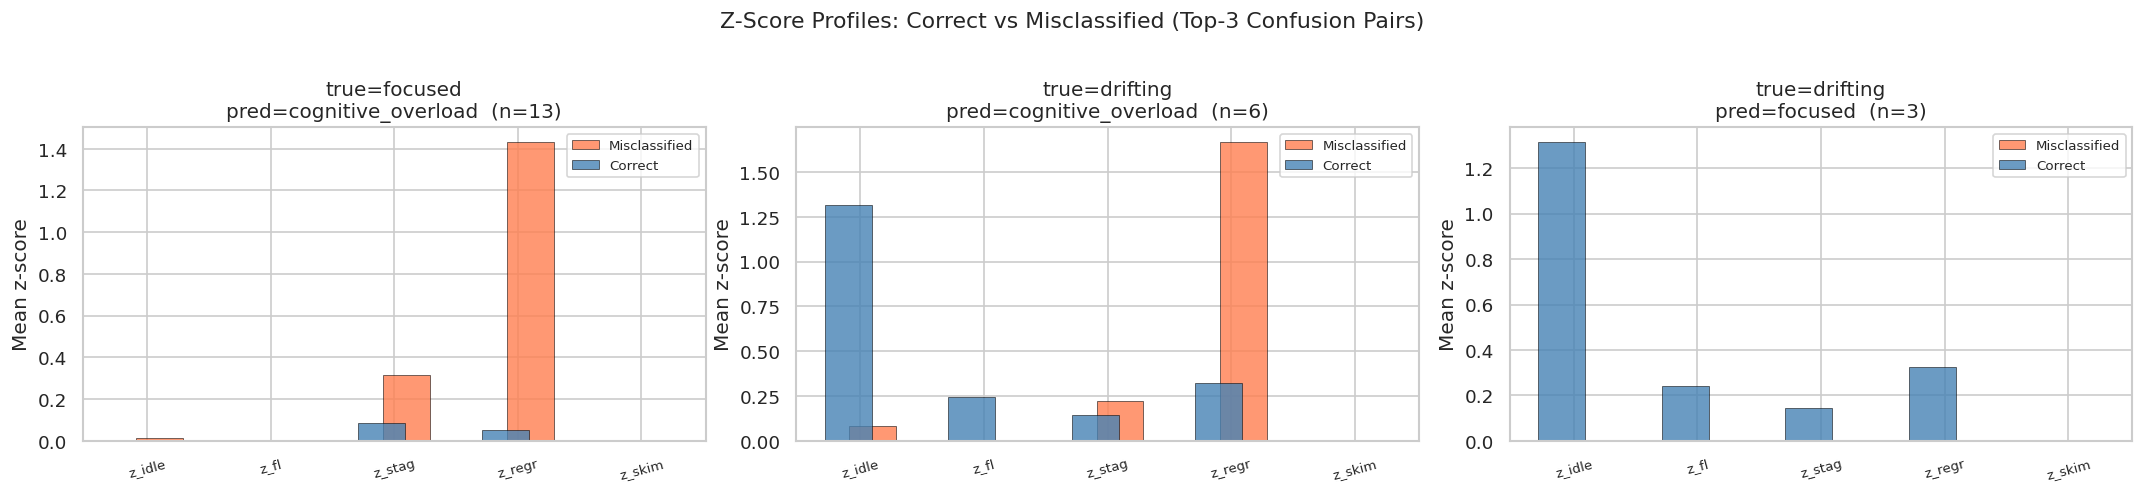


5 worst-confidence incorrect predictions:

  idx=  0  true=focused                 pred=cognitive_overload      conf=0.421  JSD=0.038
  n_batches=4  z_idle=0.15  z_fl=0.00  z_stag=1.33  panel=0.00
  note: Early packet, incomplete window: n_batches=4 and confidence=0.27 keep labels conservative. stagnation_ratio=1.00 with z_

  idx=102  true=drifting                pred=cognitive_overload      conf=0.429  JSD=0.048
  n_batches=9  z_idle=0.18  z_fl=0.00  z_stag=1.33  panel=0.00
  note: Still early: stagnation=1.00, z_stagnation=1.33, z_idle=0.18, z_burstiness=2.00, z_pause=3.00. Small positive velocity (

  idx=170  true=cognitive_overload      pred=focused                 conf=0.468  JSD=0.021
  n_batches=16  z_idle=0.00  z_fl=0.00  z_stag=0.00  panel=0.00
  note: z_reg=1.62 (real effort), velocity=0.00556 (good), very low idle=0.033. EMA=0.571 dropping. Tips into overload from z_re

  idx=157  true=focused                 pred=cognitive_overload      conf=0.470  JSD=0.025
  n_batches=

In [ ]:
# CELL 12  Error Analysis — Which Cases Fail and Why


errors, corrects = [], []
for i, (yt, yp) in enumerate(zip(y_test, rf_pred)):
    ex     = test_examples[i]
    zs     = ex.get("z_scores", {})
    ft     = ex.get("features", {})
    record = dict(
        idx=i, true=STATE_KEYS[yt], pred=STATE_KEYS[yp],
        confidence=float(rf_proba[i, yp]),
        jsd=jsd_vals[i],
        z_idle=float(zs.get("z_idle",0)),
        z_fl=float(zs.get("z_focus_loss",0)),
        z_stag=float(zs.get("z_stagnation",0)),
        z_regr=float(zs.get("z_regress",0)),
        z_skim=float(zs.get("z_skim",0)),
        panel=float(ft.get("panel_interaction_share",0)),
        n_batches=int(ft.get("n_batches", 16)),
        notes=ex.get("notes",""),
    )
    (errors if yt != yp else corrects).append(record)

print(f"Errors: {len(errors)} / {len(y_test)}  ({len(errors)/len(y_test)*100:.1f}%)")

print("\nMost common confusion pairs:")
for (t,p), n in Counter((e["true"],e["pred"]) for e in errors).most_common(6):
    print(f"  true={t:<22}  pred={p:<22}  n={n}")

# ── Top-3 confused pairs — z-score profiles ───────────────────────────────────
top_pairs = [k for k,_ in Counter((e["true"],e["pred"]) for e in errors).most_common(3)]
fig, axes = plt.subplots(1, len(top_pairs), figsize=(6*len(top_pairs), 4))
if len(top_pairs) == 1: axes = [axes]

Z_VIZ = ["z_idle","z_fl","z_stag","z_regr","z_skim"]
for ax, (true_s, pred_s) in zip(axes, top_pairs):
    err_sub  = [e for e in errors  if e["true"]==true_s and e["pred"]==pred_s]
    corr_sub = [c for c in corrects if c["true"]==true_s]
    for subset, color, label in [(err_sub,"coral","Misclassified"), (corr_sub,"steelblue","Correct")]:
        if not subset: continue
        means = [np.mean([s[z] for s in subset]) for z in Z_VIZ]
        ax.bar(np.arange(len(Z_VIZ)) + (0.2 if color=="coral" else 0), means,
               0.38, color=color, alpha=0.8, edgecolor="black", lw=0.4, label=label)
    ax.set_xticks(np.arange(len(Z_VIZ))+0.1)
    ax.set_xticklabels(Z_VIZ, fontsize=8, rotation=15)
    ax.set_title(f"true={true_s}\npred={pred_s}  (n={len(err_sub)})")
    ax.legend(fontsize=8); ax.set_ylabel("Mean z-score")

plt.suptitle("Z-Score Profiles: Correct vs Misclassified (Top-3 Confusion Pairs)", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "error_profiles.pdf"), bbox_inches="tight")
plt.show()

# ── 5 worst-confidence errors ─────────────────────────────────────────────────
print("\n5 worst-confidence incorrect predictions:")
for e in sorted(errors, key=lambda x: x["confidence"])[:5]:
    print(f"\n  idx={e['idx']:3d}  true={e['true']:<22}  pred={e['pred']:<22}  conf={e['confidence']:.3f}  JSD={e['jsd']:.3f}")
    print(f"  n_batches={e['n_batches']}  z_idle={e['z_idle']:.2f}  z_fl={e['z_fl']:.2f}  z_stag={e['z_stag']:.2f}  panel={e['panel']:.2f}")
    if e["notes"]:
        print(f"  note: {e['notes'][:120]}")

## Cell 13 — Robustness + Fairness check

Robustness: sensitivity analysis over n_estimators validates that 300 trees
is a stable operating point (Macro F1 plateau).  This justifies the
computational cost vs a smaller forest.

Fairness / subgroup analysis: per-user F1 variance checks whether the
classifier is uniformly accurate across users, or whether certain user
profiles are systematically disadvantaged — a requirement for any system deployed in an ADHD support context.

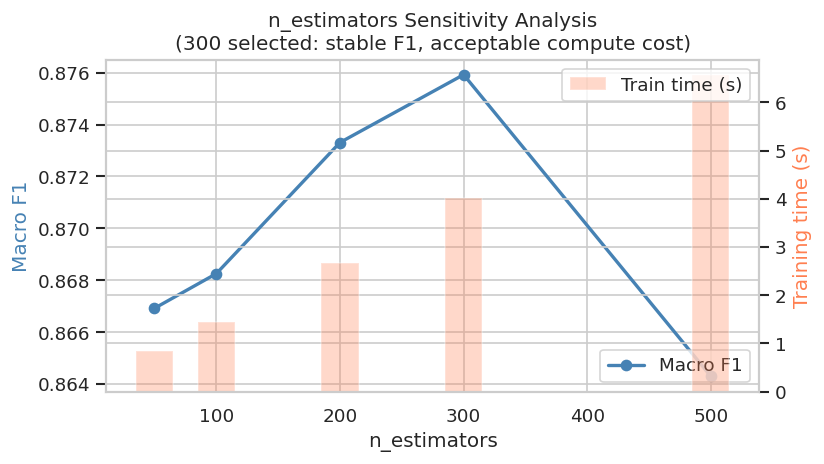


n_estimators sensitivity:
  n=  50  Macro F1=0.8669  train_time=0.83s
  n= 100  Macro F1=0.8683  train_time=1.44s
  n= 200  Macro F1=0.8733  train_time=2.67s
  n= 300  Macro F1=0.8759  train_time=4.01s
  n= 500  Macro F1=0.8643  train_time=6.56s

Per-user Macro F1 (test set only, min 3 samples):
  user_244   n=203  F1=0.7828  ███████████████
  user_248   n= 25  F1=1.0000  ████████████████████
  user_249   n= 25  F1=0.4898  █████████

  Mean F1 across users : 0.7575
  Std F1 across users  : 0.2091
  High variance would indicate the classifier is not equitably calibrated across users.


In [ ]:
# CELL 13  Robustness + Fairness Check

# ── n_estimators sensitivity ──────────────────────────────────────────────────
n_est_range  = [50, 100, 200, 300, 500]
f1_by_n      = []
time_by_n    = []

for n in n_est_range:
    t0 = time.time()
    rf_n = RandomForestClassifier(n_estimators=n, class_weight="balanced",
                                   random_state=SEED, n_jobs=-1)
    rf_n.fit(X_train, y_train)
    cal_n = CalibratedClassifierCV(rf_n, method="isotonic", cv=5)
    cal_n.fit(X_val, y_val)
    yp_n = np.argmax(cal_n.predict_proba(X_test), axis=1)
    f1_by_n.append(f1_score(y_test, yp_n, average="macro", zero_division=0))
    time_by_n.append(time.time() - t0)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()
ax1.plot(n_est_range, f1_by_n, "o-", color="steelblue", lw=2, label="Macro F1")
ax2.bar(n_est_range, time_by_n, width=30, alpha=0.3, color="coral", label="Train time (s)")
ax1.set_xlabel("n_estimators"); ax1.set_ylabel("Macro F1", color="steelblue")
ax2.set_ylabel("Training time (s)", color="coral")
ax1.set_title("n_estimators Sensitivity Analysis\n(300 selected: stable F1, acceptable compute cost)")
ax1.legend(loc="lower right"); ax2.legend(loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "sensitivity_n_estimators.pdf"), bbox_inches="tight")
plt.show()

print(f"\nn_estimators sensitivity:")
for n, f1, t in zip(n_est_range, f1_by_n, time_by_n):
    print(f"  n={n:4d}  Macro F1={f1:.4f}  train_time={t:.2f}s")

# ── Per-user F1 breakdown ─────────────────────────────────────────────────────
test_user_ids = [raw[i]["user_id"] for i in test_idx]
user_f1 = {}
for uid in sorted(set(test_user_ids)):
    mask = np.array([u == uid for u in test_user_ids])
    if mask.sum() < 3: continue
    f1_u = f1_score(y_test[mask], rf_pred[mask], average="macro", zero_division=0)
    user_f1[uid] = (f1_u, int(mask.sum()))

print(f"\nPer-user Macro F1 (test set only, min 3 samples):")
for uid, (f1, n) in sorted(user_f1.items()):
    bar = "█" * int(f1 * 20)
    print(f"  user_{uid:<5} n={n:3d}  F1={f1:.4f}  {bar}")

f1_vals_list = [v for v, _ in user_f1.values()]
print(f"\n  Mean F1 across users : {np.mean(f1_vals_list):.4f}")
print(f"  Std F1 across users  : {np.std(f1_vals_list):.4f}")
print(f"  High variance would indicate the classifier is not equitably calibrated across users.")

## INDEX Generation

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# RUN INDEX — append this run's headline metrics to the master index
# ═══════════════════════════════════════════════════════════════════════════════
index_path = os.path.join(OUTPUT_DIR, "runs_index.json")
index = []
if os.path.exists(index_path):
    with open(index_path) as f:
        index = json.load(f)

index.append({
    "run":           RUN_NUM,
    "run_dir":       RUN_DIR,
    "macro_f1":      results["macro_f1"],
    "accuracy":      results["accuracy"],
    "roc_auc":       results["roc_auc"],
    "ece":           results["ece"],
    "drifting_f1":   results["per_class_f1"].get("drifting"),
    "n_features":    N_FEATURES,
    "best_n_est":    search.best_params_.get("n_estimators"),
    "best_max_depth":search.best_params_.get("max_depth"),
})
index.sort(key=lambda r: r["macro_f1"], reverse=True)

with open(index_path, "w") as f:
    json.dump(index, f, indent=2)

print(f"\n{'='*60}")
print(f"  RUN {RUN_NUM:03d} COMPLETE")
print(f"  Macro F1   : {results['macro_f1']}")
print(f"  Accuracy   : {results['accuracy']}")
print(f"  Drifting F1: {results['per_class_f1'].get('drifting')}")
print(f"  Saved to   : {RUN_DIR}")
print(f"  All runs   : {index_path}")
print(f"{'='*60}")


  RUN 006 COMPLETE
  Macro F1   : 0.8995
  Accuracy   : 0.8893
  Drifting F1: 0.8148
  Saved to   : /content/drive/MyDrive/exports/RF/run_006
  All runs   : /content/drive/MyDrive/exports/RF/runs_index.json


# LLM Intervention Generator Training